<a href="https://www.kaggle.com/code/nithinreddy600/q10-market-research-component?scriptVersionId=320558444" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Q10. What does the tracker show about the role of CNY/RMB in global payments and trade finance?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Kaggle path first, local/current folder second
DATA_PATH = Path("/kaggle/input/datasets/nithinreddy600/dbs-research")
if not (DATA_PATH / "swift_currency_tracker_all_reports.csv").exists():
    DATA_PATH = Path(".")

OUTPUT_PATH = Path("/kaggle/working")
if not OUTPUT_PATH.exists():
    OUTPUT_PATH = Path(".")
OUTPUT_PATH.mkdir(exist_ok=True)

swift = pd.read_csv(DATA_PATH / "swift_currency_tracker_all_reports.csv")
swift.columns = swift.columns.astype(str).str.strip()

print("SWIFT dataset loaded:", swift.shape)
print("Columns:")
for i, c in enumerate(swift.columns):
    print(i, repr(c))

display(swift.head())


SWIFT dataset loaded: (288, 9)
Columns:
0 'report_month'
1 'data_month'
2 'source_report_name'
3 'metric'
4 'category'
5 'currency_or_economy'
6 'value'
7 'unit'
8 'notes'


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,Rank 5


In [2]:
def find_col(df, keywords):
    for key in keywords:
        matches = [c for c in df.columns if key.lower().replace(" ", "_") in c.lower()]
        if matches:
            return matches[0]
    return None

def find_value_col(df):
    for c in df.columns:
        if c.lower().strip() == "value":
            return c
    scores = {}
    for c in df.columns:
        temp = df[c].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        scores[c] = pd.to_numeric(temp, errors="coerce").notna().sum()
    return max(scores, key=scores.get)

value_col = find_value_col(swift)
currency_col = find_col(swift, ["currency_or_economy", "currency/economy", "currency", "economy"])
metric_col = find_col(swift, ["metric"])
category_col = find_col(swift, ["category"])
rank_col = find_col(swift, ["rank"])
month_col = find_col(swift, ["report_month", "report month", "month", "date"])
data_month_col = find_col(swift, ["data_month", "data month"])

swift[value_col] = (
    swift[value_col].astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)
swift[value_col] = pd.to_numeric(swift[value_col], errors="coerce")

print("Using value column:", value_col)
print("Using currency/economy column:", currency_col)
print("Using metric column:", metric_col)
print("Using category column:", category_col)
print("Using rank column:", rank_col)
print("Using report month column:", month_col)
print("Using data month column:", data_month_col)

# Parse month columns with the exact format to remove the UserWarning
# Example values in this file: "January 2026", "February 2026", "March 2026", "April 2026"
if month_col:
    swift["_report_month_parsed"] = pd.to_datetime(
        swift[month_col].astype(str).str.strip(),
        format="%B %Y",
        errors="coerce"
    )

if data_month_col:
    swift["_data_month_parsed"] = pd.to_datetime(
        swift[data_month_col].astype(str).str.strip(),
        format="%B %Y",
        errors="coerce"
    )

# Tell the exact analysis period before filtering to the latest month
if data_month_col and swift["_data_month_parsed"].notna().sum() > 0:
    start_date = swift["_data_month_parsed"].min().strftime("%B %Y")
    end_date = swift["_data_month_parsed"].max().strftime("%B %Y")
    print(f"Analysis conducted from {start_date} to {end_date} based on data_month.")

if month_col and swift["_report_month_parsed"].notna().sum() > 0:
    report_start = swift["_report_month_parsed"].min().strftime("%B %Y")
    report_end = swift["_report_month_parsed"].max().strftime("%B %Y")
    print(f"Reports covered from {report_start} to {report_end} based on report_month.")

df = swift.copy()

# Keep the same logic as the older notebook: use the latest report month for the table and chart
if month_col:
    parsed_month = df["_report_month_parsed"]
    if parsed_month.notna().sum() > 0:
        df["_parsed_month"] = parsed_month
        latest_month = df["_parsed_month"].max()
        df = df[df["_parsed_month"] == latest_month]
        print("Latest report month used for chart:", latest_month.strftime("%B %Y"))
        if data_month_col and "_data_month_parsed" in df.columns:
            latest_data_month = df["_data_month_parsed"].max()
            print("Latest data month shown in chart:", latest_data_month.strftime("%B %Y"))
    else:
        print("Month column found, but dates could not be parsed. Using all rows.")
else:
    print("No month column found. Using all rows.")

work = df.copy()
rmb_rows = work[work.apply(
    lambda row: row.astype(str).str.contains("CNY|RMB|Renminbi|Yuan", case=False, na=False).any(),
    axis=1
)]
display(rmb_rows.head(20))
rmb_rows.to_csv(OUTPUT_PATH / "Q10_RMB_CNY_rows.csv", index=False)

if metric_col and len(rmb_rows) > 0:
    rmb_summary = rmb_rows.groupby(metric_col, as_index=False)[value_col].max().sort_values(value_col, ascending=False)
else:
    cols = [c for c in [currency_col, value_col] if c is not None]
    rmb_summary = rmb_rows[cols].dropna().sort_values(value_col, ascending=False) if len(cols) == 2 else rmb_rows.head(10)

display(rmb_summary.head(10))
rmb_summary.to_csv(OUTPUT_PATH / "Q10_RMB_CNY_payment_trade_finance_summary.csv", index=False)


Using value column: value
Using currency/economy column: currency_or_economy
Using metric column: metric
Using category column: category
Using rank column: None
Using report month column: report_month
Using data month column: data_month
Analysis conducted from December 2025 to March 2026 based on data_month.
Reports covered from January 2026 to April 2026 based on report_month.
Latest report month used for chart: April 2026
Latest data month shown in chart: March 2026


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,notes,_report_month_parsed,_data_month_parsed,_parsed_month
150,April 2026,March 2026,Global Currency Tracker,Global Payment Share,Currency Ranking,CNY,3.10,%,Rank 5,2026-04-01,2026-03-01,2026-04-01
171,April 2026,March 2026,Global Currency Tracker,International Payment Share (ex-Eurozone),Currency Ranking,CNY,2.44,%,Rank 6,2026-04-01,2026-03-01,2026-04-01
186,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Hong Kong,75.23,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
187,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,United Kingdom,6.90,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
188,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Singapore,4.37,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
189,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,United States,2.81,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
190,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,France,1.80,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
191,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Taiwan,1.34,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
192,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Macao,1.29,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01
193,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,South Korea,1.14,%,Clearing centre,2026-04-01,2026-03-01,2026-04-01


,metric,value
3,Offshore RMB by Economy,75.23
0,FX Spot Economies (RMB),39.47
4,Trade Finance Share,8.04
1,Global Payment Share,3.10
2,International Payment Share (ex-Eurozone),2.44


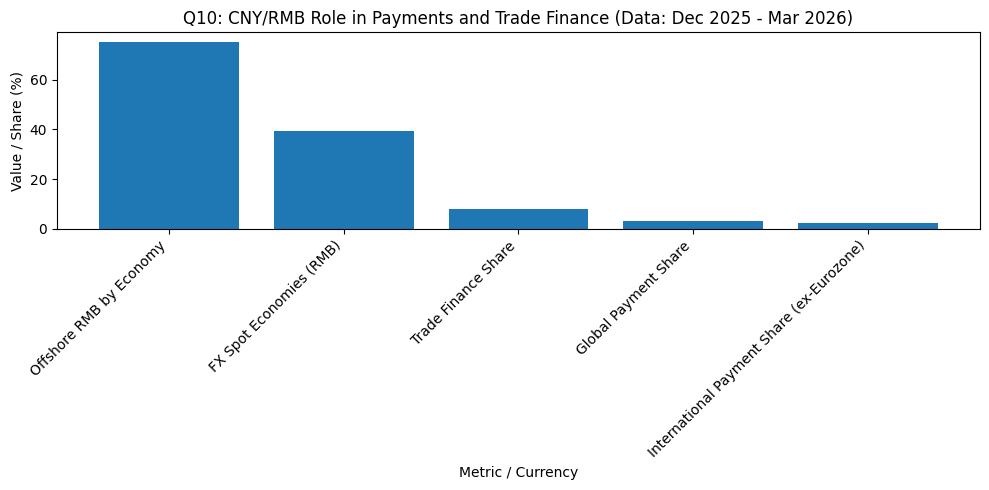

In [3]:
if len(rmb_summary) > 0 and value_col in rmb_summary.columns:
    xcol = metric_col if metric_col and metric_col in rmb_summary.columns else rmb_summary.columns[0]
    plt.figure(figsize=(10,5))
    plt.bar(rmb_summary[xcol].astype(str).head(10), rmb_summary[value_col].head(10))
    plt.title("Q10: CNY/RMB Role in Payments and Trade Finance (Data: Dec 2025 - Mar 2026)")
    plt.xlabel("Metric / Currency")
    plt.ylabel("Value / Share (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "Q10_RMB_CNY_summary_chart.png", dpi=300)
    plt.show()
else:
    print("No RMB/CNY rows found. Check the displayed column values.")


## Short answer

The analysis uses Global Currency Tracker data from **December 2025 to March 2026**. The latest chart/table uses the **April 2026 report**, which reports **March 2026 data**. The tracker shows CNY/RMB's role through its share and ranking in global payments, international payments, trade finance, and FX spot activity. In the latest data, CNY/RMB appears in the tracker but remains much smaller than USD, showing that RMB is internationally used but not dominant.
